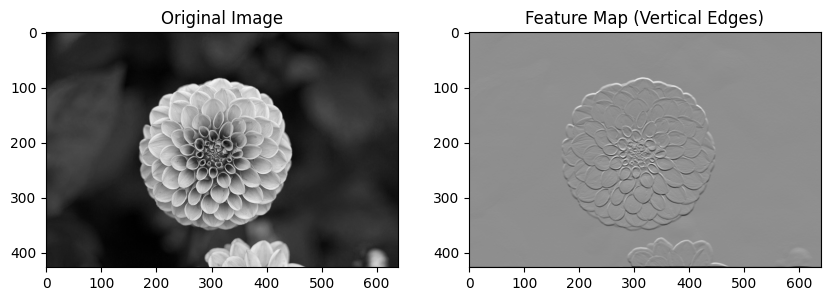

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image

# Load and preprocess
china = load_sample_image("flower.jpg") / 255
image = tf.image.rgb_to_grayscale(china)
image = tf.cast(image, tf.float32)  # Ensure float32
image = tf.expand_dims(image, axis=0)

# Vertical edge kernel (Sobel)
vertical_edge_kernel = tf.constant([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=tf.float32)

kernel = tf.reshape(vertical_edge_kernel, [3, 3, 1, 1])

# Convolution
feature_map = tf.nn.conv2d(image, kernel, strides=1, padding="SAME")

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image[0, :, :, 0], cmap='gray')
plt.title("Original Image")
plt.axis('on')

plt.subplot(1, 2, 2)
plt.imshow(feature_map[0, :, :, 0], cmap='gray')
plt.title("Feature Map (Vertical Edges)")
plt.axis('on')
plt.show()


In [2]:
import tensorflow as tf
from tensorflow import keras

input_tensor = tf.random.normal([1, 28, 28, 1])


conv_layer = keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu')


output_tensor = conv_layer(input_tensor)

print("Input Shape:", input_tensor.shape)
print("Output Shape:", output_tensor.shape)



Input Shape: (1, 28, 28, 1)
Output Shape: (1, 28, 28, 32)


In [3]:

pool_layer = keras.layers.MaxPooling2D(pool_size=2)


pooled_output = pool_layer(output_tensor)

print("Shape before pooling:", output_tensor.shape)
print("Shape after pooling:", pooled_output.shape)



Shape before pooling: (1, 28, 28, 32)
Shape after pooling: (1, 14, 14, 32)


In [4]:
keras.layers.Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')

<Conv2D name=conv2d_1, built=False>

In [ ]:
import tensorflow as tf
from tensorflow import keras

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
# Normalize pixel values to [0, 1]
X_train = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flatten labels (they are loaded as shape (n,1))
y_train = y_train_full.flatten()
y_test = y_test.flatten()

# Optional: one-hot encode labels if using categorical crossentropy
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)
print("Shape of training images:", X_train.shape)



A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
 23298048/170498071 ━━━━━━━━━━━━━━━━━━━━ 58:02 24us/step

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

# Print dataset information
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("\nFirst Image Shape:", X_train[0].shape)
print("First Image Label:", y_train[0][0])
print("Class Name:", class_names[int(y_train[0][0])])

# Display first 10 images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



model = keras.Sequential([
    
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=2),
    
    layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),

    
    layers.Flatten(),
    
   
    layers.Dense(64, activation='relu'),
    
   
    layers.Dense(10, activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


model.summary()


In [ ]:

print("Starting CNN training...")
history = model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    batch_size=64,
    validation_data=(X_test, y_test)
)
print("Training finished.")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df.plot(figsize=(12, 8), grid=True, title="CNN Learning Curves for CIFAR-10", ylim=(0,1))
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Choose any test image
image_index = 0

# Predict the selected image
prediction = model.predict(X_test[image_index:image_index+1])

# Get predicted class
predicted_class = class_names[np.argmax(prediction)]

# Display the image
plt.figure(figsize=(4,4))
plt.imshow(X_test[image_index])
plt.axis("off")
plt.title("Predicted Class: " + predicted_class)
plt.show()
print("Predicted Class:", predicted_class)


NameError: name 'model' is not defined